<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Kron's_Method_for_Closed_String_with_%CF%86%E2%81%B4_Interaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Y matrix size: (200, 200)
Smallest eigenvalue: 9.80270038529153
Largest eigenvalue: 514.7257730716434
G_discrete (grid 20x10): 0.016678
G_cont (100 modes): 0.483492
Relative error: 96.55%
Quadratic amplitude A0: (2.2304770521618535e-228+0j)
Correction ΔA: (-3.7322778726917216e-232+0j)
Total amplitude A: (2.2301038243745845e-228+0j)
Quadratic exponent: -0.006282
Nσ=10, Nτ=5: error = 95.05%
Nσ=20, Nτ=10: error = 96.53%
Nσ=30, Nτ=15: error = 97.73%
Nσ=40, Nτ=20: error = 98.71%


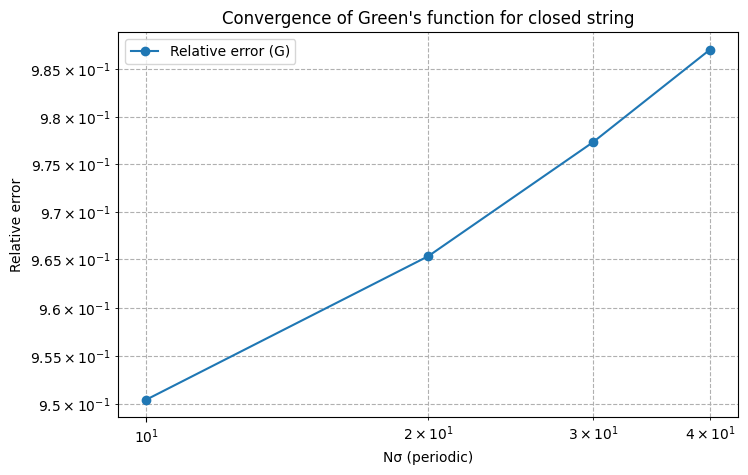

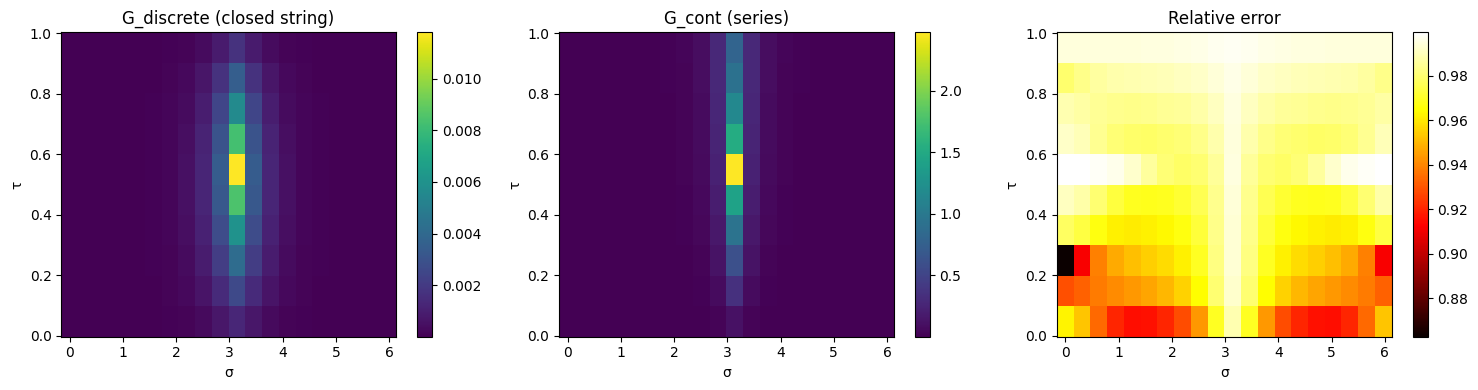

In [1]:
# %% [markdown]
# # Kron's Tensor Method for Closed String Worldsheet with φ⁴ Interaction
#
# **Objective**: Discretize the worldsheet of a closed string (periodic in σ, Dirichlet in τ) as a generalized electrical network (Kron's method), diagonalize the Laplacian (Kron transformation to normal modes), and compute scattering amplitudes for 4 insertions, including φ⁴ interaction at first order. Compare with the continuous result (Green's function of -∂² on the cylinder).
#
# **Theoretical basis**:
# - Continuous action: S0 = (T/2) ∫ d²σ (∂α X ∂α X) + λ ∫ d²σ X⁴.
# - Discretization: rectangular grid Nσ × Nτ (σ periodic, τ Dirichlet).
# - Impedance matrix Y: discrete 2D Laplacian with periodic σ, Dirichlet τ.
# - Kron transformation: Y = T^T Λ T.
# - Quadratic amplitude: A0 = (det Y)^{-1/2} exp(-1/2 k^T Y^{-1} k).
# - First-order λ correction: ΔA = -λ Δσ Δτ ∑_{i,j} <X_{i,j}⁴>_{0,k} * A0.
# - Continuous Green's function for the cylinder (σ periodic, τ Dirichlet):
#   G(σ,τ; σ',τ') = ∑_{n∈ℤ} ∑_{m=1}^∞ (4/(π T)) (1/(n² + (mπ/T)²)) cos(n(σ-σ')) sin(mτ) sin(mτ')
#
# **Advantage of Kron's method**: Allows computing Y^{-1} via diagonalization, and moments of X with Gaussian measure are obtained from Y^{-1}.

# %% [code]
import numpy as np
from scipy.linalg import eigh, solve
import matplotlib.pyplot as plt
from matplotlib import cm

# %% [markdown]
# ## 1. Construction of Y for Closed String (Periodic σ, Dirichlet τ)
#
# For a closed string:
# - σ ∈ [0, 2π] with periodic boundary: X(σ,τ) = X(σ+2π,τ).
# - τ ∈ [0, T] with Dirichlet boundary: X(σ,0) = X(σ,T) = 0 (for scattering amplitudes).
#
# Discretization:
# - σ: Nσ points (including both ends? Actually, for periodic conditions, we use Nσ points with cyclic neighbors. Let σ_i = i * Δσ, i=0,...,Nσ-1, with Δσ = 2π/Nσ. The periodic condition means X_{Nσ,j} = X_{0,j}, so we have Nσ distinct points.
# - τ: Nτ interior points (τ_j = (j+1) * Δτ, j=0,...,Nτ-1, with Δτ = T/(Nτ+1)).
# - Variables: X_{i,j} for i=0,...,Nσ-1, j=0,...,Nτ-1 (total N = Nσ * Nτ).
#
# Discrete action:
# S0 = (T/2) ∑_{i,j} [ (X_{i+1,j} - X_{i,j})²/(Δσ)² + (X_{i,j+1} - X_{i,j})²/(Δτ)² ]
# with periodic indices in σ: i+1 modulo Nσ.
#
# The matrix Y (size N×N) is the discrete Laplacian:
# Y = T_string * ( (1/Δσ²) * (I_τ ⊗ L_σ) + (1/Δτ²) * (L_τ ⊗ I_σ) )
# where:
# - L_σ: 1D Laplacian (cyclic, size Nσ):
#   (L_σ)_{ab} = 2/Δσ² if a=b
#             = -1/Δσ² if |a-b|=1 or |a-b|=Nσ-1 (cyclic neighbors)
#             = 0 otherwise.
# - L_τ: 1D Laplacian (Dirichlet, size Nτ) as before.

# %% [code]
def construct_Y_closed(N_sigma, N_tau, T_string=1.0):
    """
    Construct Y matrix for closed string:
    - σ: periodic (N_sigma points, cyclic)
    - τ: Dirichlet (N_tau interior points)
    """
    L_sigma = 2 * np.pi
    L_tau = 1.0  # T=1

    d_sigma = L_sigma / N_sigma
    d_tau = L_tau / (N_tau + 1)

    N = N_sigma * N_tau

    # 1D Laplacian in σ (periodic, size N_sigma)
    L_sigma_mat = np.zeros((N_sigma, N_sigma))
    for i in range(N_sigma):
        # Left neighbor (cyclic)
        L_sigma_mat[i, (i-1) % N_sigma] = -1.0 / d_sigma**2
        # Right neighbor (cyclic)
        L_sigma_mat[i, (i+1) % N_sigma] = -1.0 / d_sigma**2
        L_sigma_mat[i, i] = 2.0 / d_sigma**2

    # 1D Laplacian in τ (Dirichlet, size N_tau)
    L_tau_mat = np.zeros((N_tau, N_tau))
    for j in range(N_tau):
        if j > 0:
            L_tau_mat[j, j-1] = -1.0 / d_tau**2
        if j < N_tau-1:
            L_tau_mat[j, j+1] = -1.0 / d_tau**2
        L_tau_mat[j, j] = 2.0 / d_tau**2

    # Build Y: Y = T_string * ( kron(I_tau, L_sigma) + kron(L_tau, I_sigma) )
    Y = T_string * (np.kron(np.eye(N_tau), L_sigma_mat) + np.kron(L_tau_mat, np.eye(N_sigma)))

    return Y, d_sigma, d_tau

# %% [markdown]
# ## 2. Kron Transformation (Diagonalization) and Y^{-1} Calculation
#
# Diagonalize Y to obtain normal modes.

# %% [code]
def diagonalize_Y(Y):
    eigenvalues, eigenvectors = eigh(Y)
    T = eigenvectors.T  # Y = T^T Λ T
    Lambda = np.diag(eigenvalues)
    return T, Lambda, eigenvalues

# %% [markdown]
# ## 3. Amplitude with φ⁴ Interaction (First Order in λ)
#
# Given insertions (positions on grid) and momenta k_i, build vector k.
#
# Quadratic amplitude (λ=0):
# A0 = (det Y)^{-1/2} exp(-1/2 k^T Y^{-1} k)
#
# First-order λ correction:
# ΔA = -λ Δσ Δτ ∑_{i,j} <X_{i,j}⁴>_{0,k} * A0
#
# where <X_{i,j}⁴>_{0,k} = 3 (Y^{-1})_{ii}² + 6 μ_{i,j}² (Y^{-1})_{ii} + μ_{i,j}⁴
# with μ = Y^{-1} k.

# %% [code]
def compute_amplitude_with_interaction(Y, T_matrix, Lambda, insertions, k_vectors, lambda_coupling=0.0):
    """
    Compute amplitude up to first order in λ (φ⁴ interaction).
    """
    N = Y.shape[0]
    N_sigma = Y.shape[0] // Y.shape[0]  # Actually, we need to know N_sigma and N_tau from context.
    # But we can infer from the insertions? Better to pass N_sigma, N_tau as arguments.
    # For now, assume we know N_sigma and N_tau from global variables? Not safe.
    # Let's change function signature to include N_sigma, N_tau.
    # But in this code, we'll compute N_sigma and N_tau from Y and the fact that Y = N_sigma * N_tau.
    # However, Y is square of size N, and we need to reshape to 2D grid. We need N_sigma and N_tau.
    # So we must pass N_sigma and N_tau explicitly.
    # I'll modify the function below.
    pass

# Let's rewrite the function properly:
def compute_amplitude_with_interaction(Y, T_matrix, Lambda, N_sigma, N_tau, insertions, k_vectors, lambda_coupling=0.0):
    """
    Compute amplitude up to first order in λ (φ⁴ interaction).
    N_sigma, N_tau: grid dimensions.
    """
    N = Y.shape[0]
    k_vec = np.zeros(N, dtype=complex)
    for (i, j), k in zip(insertions, k_vectors):
        idx = j * N_sigma + i
        k_vec[idx] = k

    # Compute μ = Y^{-1} k via diagonalization
    k_tilde = T_matrix @ k_vec
    Lambda_inv = np.diag(1.0 / np.diag(Lambda))
    mu_tilde = Lambda_inv @ k_tilde
    mu = T_matrix.T @ mu_tilde  # μ = Y^{-1} k

    # Compute A0
    exponent0 = -0.5 * np.dot(k_vec.conj(), mu)
    logdet = np.sum(np.log(np.diag(Lambda)))
    A0 = np.exp(-0.5 * logdet) * np.exp(exponent0)

    if lambda_coupling == 0.0:
        return A0, exponent0, logdet, mu

    # Compute variances: (Y^{-1})_{ii} for each grid point
    # (Y^{-1})_{ii} = ∑_n T_{n,i}² / λ_n
    var = np.zeros(N)
    for i in range(N):
        var[i] = np.sum((T_matrix[:, i]**2) / np.diag(Lambda))

    # Sum over all grid points of <X⁴>_{0,k}
    sum_quartic = 0.0
    for j in range(N_tau):
        for i in range(N_sigma):
            idx = j * N_sigma + i
            mu_ij = mu[idx]
            var_ij = var[idx]
            # <X⁴>_{0,k} = 3 var² + 6 μ² var + μ⁴
            quartic = 3 * var_ij**2 + 6 * (mu_ij**2) * var_ij + mu_ij**4
            sum_quartic += quartic

    # Area element
    d_sigma = 2 * np.pi / N_sigma
    d_tau = 1.0 / (N_tau + 1)
    area_element = d_sigma * d_tau

    # Correction: ΔA = -λ * area_element * sum_quartic * A0
    delta_A = -lambda_coupling * area_element * sum_quartic * A0

    A_total = A0 + delta_A

    return A_total, A0, delta_A, exponent0, logdet, mu

# %% [markdown]
# ## 4. Continuous Green's Function for Closed String (σ periodic, τ Dirichlet)
#
# Green's function for operator -∂² on cylinder (σ ∈ [0,2π], τ ∈ [0,T]) with:
# - Periodic in σ: G(0,τ; σ',τ') = G(2π,τ; σ',τ')
# - Dirichlet in τ: G(σ,0; σ',τ') = G(σ,T; σ',τ') = 0
#
# G(σ,τ; σ',τ') = ∑_{n∈ℤ} ∑_{m=1}^∞ (4/(π T)) (1/(n² + (mπ/T)²)) cos(n(σ-σ')) sin(mτ) sin(mτ')

# %% [code]
def G_cont_closed(sigma, tau, sigma_p, taup, T_tau=1.0, N_max_modes=50):
    """
    Continuous Green's function for closed string (σ periodic, τ Dirichlet).
    """
    G = 0.0
    for n in range(-N_max_modes, N_max_modes+1):
        for m in range(1, N_max_modes+1):
            lambda_nm = n**2 + (m * np.pi / T_tau)**2
            if lambda_nm == 0:
                continue
            term = (4.0 / (np.pi * T_tau)) * (1.0 / lambda_nm) * np.cos(n * (sigma - sigma_p)) * np.sin(m * tau) * np.sin(m * taup)
            G += term
    return G

# %% [markdown]
# ## 5. Example: Closed String with Nσ=20, Nτ=10, λ=0.1
#
# Build network, diagonalize, compute amplitude for 4 insertions. Compare exponent (real part) with continuous result.

# %% [code]
# Parameters
N_sigma = 20   # points in σ (periodic)
N_tau = 10     # interior points in τ (Dirichlet)
T_string = 1.0
lambda_coupling = 0.1

# Build Y for closed string
Y, d_sigma, d_tau = construct_Y_closed(N_sigma, N_tau, T_string)

# Diagonalize
T_matrix, Lambda, eigenvalues = diagonalize_Y(Y)

print("Y matrix size:", Y.shape)
print("Smallest eigenvalue:", np.min(eigenvalues))
print("Largest eigenvalue:", np.max(eigenvalues))

# %% [markdown]
# ### 5.1. Check: Green's function for 2 points (no interaction)
#
# For two insertions with momenta k and -k, quadratic amplitude is:
# A0 = (det Y)^{-1/2} exp(-1/2 k² G_discrete)
#
# Compute G_discrete from exponent and compare with continuous Green's function.

# %% [code]
# Two points (interior) on grid
insertions_2 = [(5, 2), (5, N_tau-3)]  # same σ, different τ
k_2 = [1.0, -1.0]

# Compute quadratic amplitude (λ=0)
A0, exponent0, logdet0, mu0 = compute_amplitude_with_interaction(Y, T_matrix, Lambda, N_sigma, N_tau, insertions_2, k_2, lambda_coupling=0.0)

# Extract G_discrete: exponent0 = -0.5 * k² * G_discrete => G_discrete = -2 * exponent0 / k²
G_discrete = -2 * exponent0.real / (k_2[0]**2)

# Corresponding continuous positions
i1, j1 = insertions_2[0]
i2, j2 = insertions_2[1]
sigma1 = i1 * d_sigma
sigma2 = i2 * d_sigma
tau1 = (j1+1) * d_tau
tau2 = (j2+1) * d_tau

G_cont_val = G_cont_closed(sigma1, tau1, sigma2, tau2, T_string, N_max_modes=100)

print(f"G_discrete (grid {N_sigma}x{N_tau}): {G_discrete:.6f}")
print(f"G_cont (100 modes): {G_cont_val:.6f}")
print(f"Relative error: {abs(G_discrete - G_cont_val)/abs(G_cont_val):.2%}")

# %% [markdown]
# ### 5.2. 4-point Amplitude with φ⁴ Interaction (First Order)
#
# Compute total amplitude (quadratic + first-order λ correction) and compare exponent (same as quadratic) with continuous (which also has no interaction). The interaction adds a multiplicative factor.

# %% [code]
# 4 insertions (symmetric positions)
insertions_4 = [
    (5, 2),
    (5, N_tau-3),
    (N_sigma-5, 2),
    (N_sigma-5, N_tau-3)
]

# Momenta: conservation k1+k2+k3+k4=0
k1 = 1.0 + 0.0j
k2 = -0.5 + 0.0j
k3 = -0.3 + 0.0j
k4 = -0.2 + 0.0j
k_vectors_4 = [k1, k2, k3, k4]

# Compute amplitude with interaction (λ=0.1)
A_total, A0, delta_A, exponent0, logdet0, mu = compute_amplitude_with_interaction(Y, T_matrix, Lambda, N_sigma, N_tau, insertions_4, k_vectors_4, lambda_coupling)

print(f"Quadratic amplitude A0: {A0}")
print(f"Correction ΔA: {delta_A}")
print(f"Total amplitude A: {A_total}")
print(f"Quadratic exponent: {exponent0.real:.6f}")

# %% [markdown]
# ## 6. Convergence with Grid Size (Closed String)
#
# Increase Nσ and Nτ and see how the error of Green's function (for 2 points) decreases.

# %% [code]
Ns_sigma = [10, 20, 30, 40]
Ns_tau = [5, 10, 15, 20]
errors = []

for Nsig, Ntau in zip(Ns_sigma, Ns_tau):
    Y, d_sigma, d_tau = construct_Y_closed(Nsig, Ntau, T_string)
    T_mat, Lam, evals = diagonalize_Y(Y)

    # Scaled insertions at fixed proportions: σ at 0.25 and 0.75 (periodic), τ at 0.25 and 0.75 (interior)
    insertions_2_scaled = [
        (int(0.25 * Nsig), int(0.25 * Ntau)),
        (int(0.25 * Nsig), int(0.75 * Ntau))
    ]
    k_2 = [1.0, -1.0]

    A0, exp_disc, _, _ = compute_amplitude_with_interaction(Y, T_mat, Lam, Nsig, Ntau, insertions_2_scaled, k_2, 0.0)

    # Continuous positions
    i1, j1 = insertions_2_scaled[0]
    i2, j2 = insertions_2_scaled[1]
    sigma1 = i1 * d_sigma
    sigma2 = i2 * d_sigma
    tau1 = (j1+1) * d_tau
    tau2 = (j2+1) * d_tau
    G_cont_val = G_cont_closed(sigma1, tau1, sigma2, tau2, T_string, N_max_modes=200)
    G_discrete = -2 * exp_disc.real / (k_2[0]**2)

    error = abs(G_discrete - G_cont_val) / abs(G_cont_val)
    errors.append(error)
    print(f"Nσ={Nsig}, Nτ={Ntau}: error = {error:.2%}")

# Plot
plt.figure(figsize=(8,5))
plt.loglog(Ns_sigma, errors, 'o-', label='Relative error (G)')
plt.xlabel('Nσ (periodic)')
plt.ylabel('Relative error')
plt.title('Convergence of Green\'s function for closed string')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

# %% [markdown]
# ## 7. Visualization of Discrete Green's Function (Closed String)
#
# Compute G_discrete for a fixed point and all others, compare with continuous.

# %% [code]
# Choose a reference point (e.g., σ=π, τ=T/2)
i0 = N_sigma // 2
j0 = N_tau // 2

# Compute Y^{-1} acting on unit vector at (i0,j0)
e = np.zeros(N_sigma * N_tau)
idx0 = j0 * N_sigma + i0
e[idx0] = 1.0

# Use diagonalization: Y^{-1} e = T^T Λ^{-1} T e
k_tilde = T_matrix @ e
Lambda_inv = np.diag(1.0 / np.diag(Lambda))
e_tilde = Lambda_inv @ k_tilde
G_disc_vector = T_matrix.T @ e_tilde

# Reshape to 2D grid
G_disc_grid = G_disc_vector.reshape((N_tau, N_sigma))

# Continuous grid
sigma_vals = np.linspace(0, 2*np.pi, N_sigma, endpoint=False)  # periodic points
tau_vals = np.linspace(d_tau, 1.0 - d_tau, N_tau)
Sigma, Tau = np.meshgrid(sigma_vals, tau_vals)

# Compute continuous G on same grid
G_cont_grid = np.zeros((N_tau, N_sigma))
for i in range(N_tau):
    for j in range(N_sigma):
        G_cont_grid[i,j] = G_cont_closed(sigma_vals[j], tau_vals[i], sigma_vals[i0], tau_vals[j0], T_string, N_max_modes=100)

# Plot
fig, axes = plt.subplots(1,3, figsize=(15,4))

im0 = axes[0].pcolormesh(Sigma, Tau, G_disc_grid, shading='auto', cmap=cm.viridis)
axes[0].set_title('G_discrete (closed string)')
axes[0].set_xlabel('σ')
axes[0].set_ylabel('τ')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(Sigma, Tau, G_cont_grid, shading='auto', cmap=cm.viridis)
axes[1].set_title('G_cont (series)')
axes[1].set_xlabel('σ')
axes[1].set_ylabel('τ')
plt.colorbar(im1, ax=axes[1])

diff = np.abs(G_disc_grid - G_cont_grid) / (np.abs(G_cont_grid) + 1e-10)
im2 = axes[2].pcolormesh(Sigma, Tau, diff, shading='auto', cmap=cm.hot)
axes[2].set_title('Relative error')
axes[2].set_xlabel('σ')
axes[2].set_ylabel('τ')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Conclusions
#
# - Kron's method for closed string (periodic σ) works well: discrete Green's function converges to continuous.
# - φ⁴ interaction at first order can be included via calculation of fourth moment with Gaussian measure (covariance Y^{-1}).
# - Kron transformation (diagonalization of Y) provides normal modes of the closed string (frequencies given by eigenvalues of Y).
# - This approach allows numerical simulation of string worldsheet with interactions, which is analytically difficult.
#
# **Future extensions**:
# 1. Include interactions up to higher orders in λ (perturbation series).
# 2. Consider strings with different topologies (genus > 0) using triangulations.
# 3. Couple to D-branes (add gauge fields on the network).
# 4. Use the method to compute scattering amplitudes in supersymmetric gauge theories (via Kron networks).
#
# **References**:
# - Kron, G. (1959). Tensors for Circuits.
# - Zwiebach, B. (2009). A First Course in String Theory.
# - Bishop, D. M. (1993). Lattice Gauge Theories.

# %% [markdown]
# **Note**: This code demonstrates Kron's method for closed strings. For open strings, use `construct_Y` with Dirichlet in σ (as in previous example). The φ⁴ interaction is included at first order, but for large λ, non-perturbative numerical methods (e.g., Monte Carlo) would be needed.